In [345]:
"""
CNN per mi predict handwritter numbers/digits 0-9
import librarit e nevojshme numpy, pandas, pyplot
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [346]:
"""
import datasetin prej kaggle, ni huge csv me tdhana per do imazhe 28x28p,
me vlera per secilin pixel te seciles foto 0-255.
poashtu edhe label qe kallxon se cili number eshte ne qat imazh.
dataseti qe e kom gjete veq ish kon i ndame ne train edhe test set.
i transponojme matricat qe me pas ma lehte tutje, edhe i pjestojm me 255 qe me na jep vlera prej 0 deri te 1
"""

train_df = pd.read_csv("dataset/mnist_train.csv")
test_df  = pd.read_csv("dataset/mnist_test.csv")

y_train = train_df["label"].values.T
X_train = train_df.drop(columns=["label"]).values.T / 255
X_test = test_df.values.T / 255

In [347]:
X_train[:, 0].shape

(784,)

In [348]:
"""
i inicializojme parametrat
H - numri i neuroneve ne hidden layer, (u dasht me experimentu deri mka dal accuracy mjaftushem)
W1 - pesha/weight ne shtresen e pare / input layer -> hidden layer
W2 - weight te hidden layer -> output
b1 - biasi ne input layer
b2 - biasi ne hidden layer
"""

def init_params():
    H = 64  # hidden size
    W1 = np.random.randn(H, 784) * np.sqrt(2/784)
    b1 = np.zeros((H, 1))

    W2 = np.random.randn(10, H) * np.sqrt(2/H)
    b2 = np.zeros((10, 1))

    return W1, b1, W2, b2



In [349]:
"""
activiation function, rectified linear unit
implementohet gjat forward pass
thjesht vlerat X<0 i kthen 0
vlerat X>0 i kthen X, dmth lineare
"""

def relu(x):
    return np.maximum(0, x)

In [350]:
"""
poashtu activation function, implementohet ne fund te forward pass
konverton ni vektor te numrave ne probabilitete 0-1
(dmth niher te dhanat hyjne ne neural network, implementohet ReLU, tani softmax, tani ne baze te outputit kthehet me backwards pass)
"""
def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)

In [351]:
"""
tdhanat futen ne neural network, shumzohen me peshat dhe ju shtohet biasi ne baze te shtreses qe jane,
implementohet relu pas hidden layer
tani output layer, tani softmax
"""
def forward_pass(W1, b1, W2, b2, X):
   Z1 = W1.dot(X) + b1
   A1 = relu(Z1)
   Z2 = W2.dot(A1) + b2
   A2 = softmax(Z2)

   return Z1, A1, Z2, A2


In [352]:
"""
vlerat e label dekodohen me One Hot Encoder edhe transponohen
"""
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max()+1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

In [353]:
"""
kthen derivatin e ReLU te ni layer te specifikum,
pretty much e kthen 1 nese Z>0
e kthen 0 nese Z<0
per arsye se derivati i ni funksionit linear gjithmone osht 1, per vlera 0 gjithmone osht 0
"""
def deriv_relu(Z):
    return (Z > 0).astype(float)


In [354]:
"""
pasi qe tdhanat i kalojne krejt layers te neural network (forward pass),
kthehen (backward pass) per me krahasu predictions me actual data,
qe me gjet errorin ne weights edhe ne bias, ne menyre qe me i adjust accordingly
"""
def backward_pass(Z1, A1, Z2, A2, W2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = W2.T.dot(dZ2) * deriv_relu(Z1)

    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2

In [355]:
"""
pas backward pass i bon update weights edhe bias ne baze te errorit edhe alpha (learning rate qe e caktojm na nfund)
"""
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 -= alpha * dW1
    b1 -= alpha * db1
    W2 -= alpha * dW2
    b2 -= alpha * db2
    return W1, b1, W2, b2


In [356]:
"""
helper functions qe mi pa qdo iterim qfare prediction bon modeli edhe sa accurate osht
"""
def get_predictions(A2):
    return np.argmax(A2, axis=0)

def get_accuracy(predictions, Y):
    return np.mean(predictions == Y)

In [357]:
"""
ktu bohet krejt procesi,
i jepim training data, sa iterime dojm me i bo edhe qfar learning rate (alpha)
per qdo iterim, kalon forward pass, backward pass tani bohen update
"""
def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_pass(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_pass(Z1, A1, Z2, A2, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if (i % 50 == 0):
            print(f"Iteration {i} done")
            print("Accuracy: ", get_accuracy(get_predictions(A2), Y))

    return W1, b1, W2, b2


In [358]:
W1, b1, W2, b2 = gradient_descent(X_train, y_train, 500, 0.05)

Iteration 0 done
Accuracy:  0.12753333333333333
Iteration 50 done
Accuracy:  0.7841666666666667
Iteration 100 done
Accuracy:  0.84425
Iteration 150 done
Accuracy:  0.8651666666666666
Iteration 200 done
Accuracy:  0.8760833333333333
Iteration 250 done
Accuracy:  0.8834333333333333
Iteration 300 done
Accuracy:  0.8894833333333333
Iteration 350 done
Accuracy:  0.8942
Iteration 400 done
Accuracy:  0.8979166666666667
Iteration 450 done
Accuracy:  0.9007


In [369]:
"""
helper functions me make ni prediction edhe me e testu,
me ane te chatit edhe e vizualizon ni sample
"""
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_pass(W1, b1, W2, b2, X)
    return get_predictions(A2)

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index].reshape(28, 28)
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28,28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [2]
Label:  2


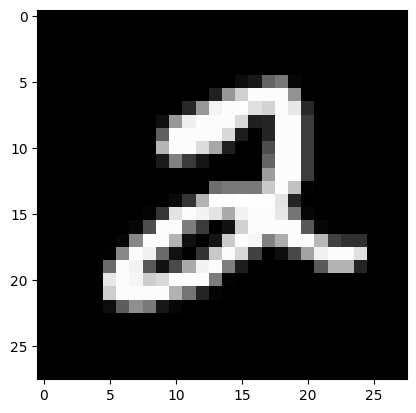

In [378]:
"""
bon predict per records te test setit,
ne parametrin e par i jepim ni vler prej 0-59999
ajo vlera osht indexi i recordit ne dataset.
"""
test_prediction(5, W1, b1, W2, b2)